In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns

In [2]:
reviews = pd.read_csv('/Users/scottsieger/letterboxd-recommender/data/reviews.csv')
ratings = pd.read_csv('/Users/scottsieger/letterboxd-recommender/data/ratings.csv')

In [3]:
reviews.head()

,Date,Name,Year,Letterboxd URI,Rating,Rewatch,Review,Tags,Watched Date
0,2024-01-04,Saltburn,2023,https://boxd.it/5umQxv,4.5,NaN,Very similar to the talented Mr Ripley which I...,NaN,2024-01-03
1,2024-01-05,The Killing of a Sacred Deer,2017,https://boxd.it/5uYxGT,2.5,NaN,Jesus Christ,NaN,2024-01-04
2,2024-01-21,Mean Girls,2024,https://boxd.it/5E8OPp,1.5,NaN,"Nothing compared to the original, but stand al...",NaN,2024-01-19
3,2024-01-27,12 Angry Men,1997,https://boxd.it/5GXPql,4.0,NaN,Had only seen the original movie adaptation. G...,NaN,2024-01-26
4,2024-01-27,L.A. Confidential,1997,https://boxd.it/5H1Q2n,4.0,NaN,I wanna be a '50s LA detective,NaN,2024-01-26


In [4]:
ratings.head()

,Date,Name,Year,Letterboxd URI,Rating
0,2023-11-08,The Usual Suspects,1995,https://boxd.it/29XE,5.0
1,2023-11-08,Good Will Hunting,1997,https://boxd.it/2ahY,5.0
2,2023-11-08,Scream,1996,https://boxd.it/24EC,5.0
3,2023-11-08,A Few Good Men,1992,https://boxd.it/29nw,5.0
4,2023-11-08,No Country for Old Men,2007,https://boxd.it/21ew,5.0


In [5]:
ratings["Rating"].value_counts().sort_index()

Rating
1.5     2
2.0     2
2.5    15
3.0    48
3.5    57
4.0    68
4.5    44
5.0    19
Name: count, dtype: int64

<Axes: xlabel='Rating'>

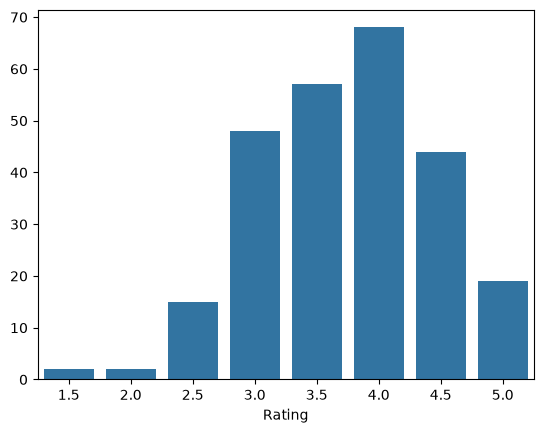

In [8]:
sns.barplot(x=ratings["Rating"].value_counts().sort_index().index, y=ratings["Rating"].value_counts().sort_index().values)

In [9]:
ratings.sort_values(
    "Rating",
    ascending=False
)[["Name", "Year", "Rating"]].head(30)

,Name,Year,Rating
0,The Usual Suspects,1995,5.0
206,Surf's Up,2007,5.0
171,Sicario,2015,5.0
126,Heat,1995,5.0
1,Good Will Hunting,1997,5.0
221,Mulholland Drive,2001,5.0
72,Free Solo,2018,5.0
182,Inherent Vice,2014,5.0
70,2001: A Space Odyssey,1968,5.0
159,G.N.A.R.,2011,5.0


In [6]:
user_movies = ratings.merge(
    reviews,
    on=["Name", "Year"],
    how="left",
    suffixes=("_rating", "_review")
)

user_movies.head()

,Date_rating,Name,Year,Letterboxd URI_rating,Rating_rating,Date_review,Letterboxd URI_review,Rating_review,Rewatch,Review,Tags,Watched Date
0,2023-11-08,The Usual Suspects,1995,https://boxd.it/29XE,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-11-08,Good Will Hunting,1997,https://boxd.it/2ahY,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-11-08,Scream,1996,https://boxd.it/24EC,5.0,2025-10-30,https://boxd.it/bxwT0p,5.0,Yes,The perfect most re-watchable movie I can't be...,NaN,2025-10-29
3,2023-11-08,A Few Good Men,1992,https://boxd.it/29nw,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-11-08,No Country for Old Men,2007,https://boxd.it/21ew,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print(user_movies.shape)
print(user_movies.columns.tolist())
user_movies.head(10)

(257, 12)
['Date_rating', 'Name', 'Year', 'Letterboxd URI_rating', 'Rating_rating', 'Date_review', 'Letterboxd URI_review', 'Rating_review', 'Rewatch', 'Review', 'Tags', 'Watched Date']


,Date_rating,Name,Year,Letterboxd URI_rating,Rating_rating,Date_review,Letterboxd URI_review,Rating_review,Rewatch,Review,Tags,Watched Date
0,2023-11-08,The Usual Suspects,1995,https://boxd.it/29XE,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-11-08,Good Will Hunting,1997,https://boxd.it/2ahY,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-11-08,Scream,1996,https://boxd.it/24EC,5.0,2025-10-30,https://boxd.it/bxwT0p,5.0,Yes,The perfect most re-watchable movie I can't be...,NaN,2025-10-29
3,2023-11-08,A Few Good Men,1992,https://boxd.it/29nw,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-11-08,No Country for Old Men,2007,https://boxd.it/21ew,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2023-11-08,Apocalypse Now,1979,https://boxd.it/6ZS,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2023-11-08,Reservoir Dogs,1992,https://boxd.it/2agc,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2023-11-08,The Grand Budapest Hotel,2014,https://boxd.it/3ZqO,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2023-11-08,The Prestige,2006,https://boxd.it/293w,4.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2023-11-08,Inglourious Basterds,2009,https://boxd.it/1JzG,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
user_movies = user_movies.rename(columns={
    "Rating_rating": "Rating",
    "Review": "Review"
})

keep_cols = [
    col for col in ["Name", "Year", "Rating", "Review"]
    if col in user_movies.columns
]

user_movies = user_movies[keep_cols]

user_movies.head()

,Name,Year,Rating,Review
0,The Usual Suspects,1995,5.0,NaN
1,Good Will Hunting,1997,5.0,NaN
2,Scream,1996,5.0,The perfect most re-watchable movie I can't be...
3,A Few Good Men,1992,5.0,NaN
4,No Country for Old Men,2007,5.0,NaN


In [8]:
user_movies.isna().sum()

Name        0
Year        0
Rating      0
Review    116
dtype: int64

In [9]:
user_movies.duplicated(subset=["Name", "Year"]).sum()

np.int64(2)

In [10]:
user_movies.to_csv("/Users/scottsieger/letterboxd-recommender/data/user_movies.csv", index=False)

In [11]:
import sys
sys.path.append("../")

from src.tmdb import TMDBClient

tmdb = TMDBClient()

movie = tmdb.find_movie(
    "Arrival",
    2016
)


movie

{'tmdb_id': 329865,
 'tmdb_title': 'Arrival',
 'original_title': 'Arrival',
 'release_date': '2016-11-10',
 'overview': 'Taking place after alien crafts land around the world, an expert linguist is recruited by the military to determine whether they come in peace or are a threat.',
 'genres': ['Drama', 'Science Fiction', 'Mystery'],
 'director': 'Denis Villeneuve',
 'cast': ['Amy Adams',
  'Jeremy Renner',
  'Forest Whitaker',
  'Michael Stuhlbarg',
  "Mark O'Brien"],
 'keywords': ['spacecraft',
  'extraterrestrial technology',
  'loss',
  'time',
  'alien',
  'language',
  'female protagonist',
  'scientist',
  'heartbreak',
  'based on short story',
  'alien contact',
  'military',
  'alien language',
  'linguist',
  'first contact',
  'communication',
  'linguistics',
  'time-manipulation',
  'complex',
  'determinism',
  'science fiction',
  'wistful',
  'incredulous',
  'hopeful'],
 'runtime': 116,
 'popularity': 24.3333,
 'vote_average': 7.633,
 'vote_count': 19789,
 'poster_url'

In [12]:
sample = user_movies.head(10)

for _, row in sample.iterrows():
    movie = tmdb.search_movie(
        row["Name"],
        row["Year"]
    )

    if movie:
        print(
            row["Name"],
            "→",
            movie["title"],
            movie["id"]
        )
    else:
        print(
            row["Name"],
            "→ NOT FOUND"
        )
        

The Usual Suspects → The Usual Suspects 629
Good Will Hunting → Good Will Hunting 489
Scream → Scream 4232
A Few Good Men → A Few Good Men 881
No Country for Old Men → No Country for Old Men 6977
Apocalypse Now → Apocalypse Now 28
Reservoir Dogs → Reservoir Dogs 500
The Grand Budapest Hotel → The Grand Budapest Hotel 120467
The Prestige → The Prestige 1124
Inglourious Basterds → Inglourious Basterds 16869


In [13]:
import sys
sys.path.append("../")
from src.tmdb import TMDBClient

tmdb = TMDBClient()

from src.tmdb import enrich_user_movies

enriched_movies = enrich_user_movies(
    user_movies,
    client=tmdb
)

enriched_movies = enriched_movies[
    [
        "Name",
        "Year",
        "Rating",
        "tmdb_id",
        "genres",
        "director",
        "cast"
    ]
]

In [14]:
enriched_movies.to_csv(
    "../data/enriched_movies.csv",
    index=False
)

In [15]:
enriched_movies.shape

(257, 7)

In [13]:
sample_enriched_movies.shape

NameError: name 'sample_enriched_movies' is not defined

In [2]:
import sys
sys.path.append("../")

from src.tmdb import TMDBClient
from src.catalog import MovieCatalog


tmdb = TMDBClient()

catalog = MovieCatalog(
    tmdb_client=tmdb
)

In [3]:
catalog.build_catalog(
    pages=2,
    min_vote_count=100,
    min_rating=5.0,
)

40

In [5]:
movie_catalog = catalog.load_catalog()

print(movie_catalog.shape)

#movie_catalog.head()

(40, 15)


In [33]:
candidates = catalog.get_candidates(
    enriched_movies
)

print(
    f"Catalog movies: {len(movie_catalog)}"
)

print(
    f"Unseen candidates: {len(candidates)}"
)

candidates[
    [
        "title",
        "year",
        "vote_average",
        "vote_count",
    ]
].head(20)

Catalog movies: 40
Unseen candidates: 32


,title,year,vote_average,vote_count
0,Spider-Man,2002,7.351,21307
1,The Avengers,2012,8.073,39540
2,Hotel Desire,2011,6.160,162
3,Avatar: Fire and Ash,2025,7.650,4244
4,Avengers: Infinity War,2018,8.200,32768
5,From Straight A's to XXX,2017,5.936,171
6,Masters of the Universe,2026,7.200,2019
7,Spider-Man: Across the Spider-Verse,2023,8.346,9152
8,Spider-Man: No Way Home,2021,7.945,22952
9,The Whisper Man,2026,6.347,226
